In [91]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.ndimage as ndi
from sklearn.cluster import KMeans
import pandas as pd

In [92]:
root = os.getcwd()
print(root)
img_gray = cv.imread("./../images/hpref.tif", cv.IMREAD_GRAYSCALE)[:, 72:552]

c:\Users\PC\Desktop\UN\OpticsWork\codefiles\thesisreproduction\23-11-KeratoconusMC\codefiles


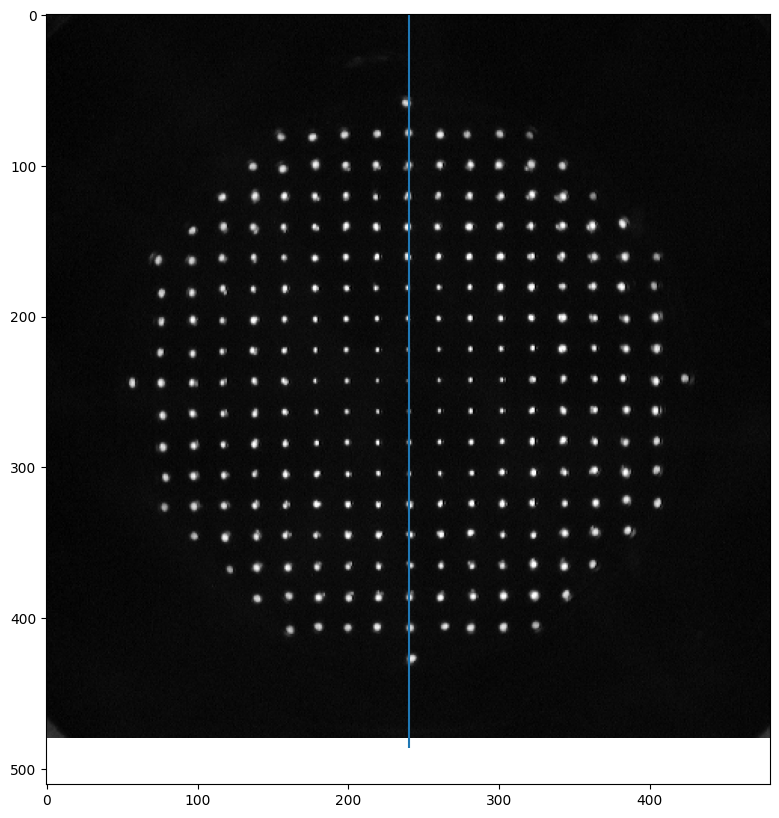

In [93]:
plt.figure(figsize=(10,10))
plt.imshow(img_gray, cmap="gray")
plt.vlines(x=240,ymin=0, ymax=486)


In [94]:
img_gray.shape

(480, 480)

Created binary mask with threshold=70.
[195  77   6   6  26]
Found 264 total blobs (including noise).

Smallest real spot (Blob #252) has 6 pixels.
Largest noise blob (Blob #253) has 3 pixels.
--- Automatically setting min_spot_size to: 4 ---
Kept 252 spots after filtering.
Calculated 252 precise sub-pixel centroids.
Sorted all centroids correctly using column clustering.
Manually inserted point (243.0, 243.0) at position 99.
Successfully saved 253 precise, sorted centroids to ./../data/hpref-centroids.txt


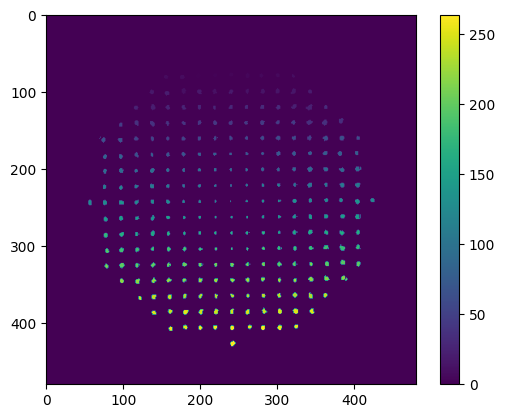

In [95]:
threshold_value = 70

expected_spots = 252
number_of_columns = 19

output_filename = './../data/hpref-centroids.txt'

# --- 2. Load the Image ---
root = os.getcwd()

# --- 3. Isolate the Spots (Get Binary Mask) ---
ret, binary_mask = cv.threshold(img_gray, threshold_value, 255, cv.THRESH_BINARY)
print(f"Created binary mask with threshold={threshold_value}.")

# --- 4. Find and Label All Spots (with Stats) ---
num_labels, labels_matrix, stats, centroids = cv.connectedComponentsWithStats(binary_mask)

plt.imshow(labels_matrix)
plt.colorbar()

print(stats[2, :])

# Get the size (area) of all blobs, skipping the background (label 0)
all_blob_sizes = stats[1:, cv.CC_STAT_AREA]
# Here, it orders from the biggest to the smallest one
all_blob_sizes_sorted = sorted(all_blob_sizes, reverse=True)

print(f"Found {len(all_blob_sizes_sorted)} total blobs (including noise).")

# --- 5. AUTOMATICALLY Find the 'min_spot_size' ---
# (This is the "diagnostic" code, now integrated)

if len(all_blob_sizes_sorted) < expected_spots:
    print("\n*** ERROR: Found fewer than {expected_spots} spots. ***")
    print("*** Try lowering the 'threshold_value' (e.g., to 50 or 40) and run again. ***")
else:
    # This is the size of your smallest "real" spot
    size_of_last_spot = all_blob_sizes_sorted[expected_spots - 1] # Index 252 is the 253rd item
    
    # This is the size of the largest "noise" blob
    size_of_first_noise = all_blob_sizes_sorted[expected_spots]   # Index 253 is the 254th item
    
    # We automatically set the minimum size to be halfway between them
    min_spot_size = (size_of_last_spot + size_of_first_noise) / 2
    
    print(f"\nSmallest real spot (Blob #{expected_spots}) has {size_of_last_spot} pixels.")
    print(f"Largest noise blob (Blob #{expected_spots + 1}) has {size_of_first_noise} pixels.")
    print(f"--- Automatically setting min_spot_size to: {int(min_spot_size)} ---")

    # --- 6. Filter out Noise ---
    valid_indices = []
    for label_id in range(1, num_labels): # Loop from 1 (skip background 0)
        if stats[label_id, cv.CC_STAT_AREA] > min_spot_size:
            valid_indices.append(label_id)
            
    print(f"Kept {len(valid_indices)} spots after filtering.")

    # --- 7. Calculate Precise Intensity-Weighted Centroids ---
    precise_centroids_yx = ndi.center_of_mass(img_gray, labels=labels_matrix, index=valid_indices)
    print(f"Calculated {len(precise_centroids_yx)} precise sub-pixel centroids.")

    # --- 8. Organize Centroids with Clustering ---
    centroids_xy = [(coord[1], coord[0]) for coord in precise_centroids_yx]
    
    # Prepare data for clustering
    x_coords = np.array([c[0] for c in centroids_xy]).reshape(-1, 1)

    # Check if we have enough points to cluster
    if len(x_coords) < number_of_columns:
        print(f"\n*** ERROR: Not enough spots ({len(x_coords)}) to create {number_of_columns} columns. ***")
        print("*** Your 'min_spot_size' might be too high or 'threshold_value' is wrong. ***")
    else:
        # Initialize and run KMeans to group spots into columns
        kmeans = KMeans(n_clusters=number_of_columns, n_init=10, random_state=0)
        column_labels = kmeans.fit_predict(x_coords)
        
        # Get the X-coordinate of each cluster center
        cluster_centers = kmeans.cluster_centers_.flatten()
        
        # Get the sorted order of the clusters
        cluster_sort_order = np.argsort(cluster_centers)
        
        # Create a map: {original_cluster_id: sorted_column_label}
        cluster_map = {original_id: sorted_id for sorted_id, original_id in enumerate(cluster_sort_order)}

        # Create a new list we can sort properly
        sortable_list = []
        for i in range(len(centroids_xy)):
            spot_xy = centroids_xy[i]
            original_cluster_id = column_labels[i]
            sorted_column_label = cluster_map[original_cluster_id]
            y_coord = spot_xy[1]
            sort_key = (sorted_column_label, y_coord)
            sortable_list.append( (sort_key, spot_xy) )

        # Sort the list based on the key (column, then y)
        sorted_list_of_tuples = sorted(sortable_list, key=lambda item: item[0])
        
        # Extract just the (x, y) coordinates, now in the perfect order
        sorted_centroids = [item[1] for item in sorted_list_of_tuples]

        print("Sorted all centroids correctly using column clustering.")
# --- *** THIS IS THE MODIFIED SECTION *** ---
        
        # --- 9. Manually Insert the Center Point ---
        # Define the point to be inserted
        manual_point = (243.0, 243.0)
        # Define the position (99th point is index 98)
        insert_index = 98


    # Check if the list has the expected 196 spots
        if len(sorted_centroids) == expected_spots:
            # Insert the manual point into the list
            sorted_centroids.insert(insert_index, manual_point)
            print(f"Manually inserted point {manual_point} at position 99.")
        else:
            print(f"*** WARNING: Did not insert manual point. Expected 196 spots but found {len(sorted_centroids)}. ***")


        # --- 10. Save to File ---
        with open(output_filename, 'w') as f:
            for i, (x_coord, y_coord) in enumerate(sorted_centroids):
                label = i + 1
                # Save in the format: label X_float Y_float
                # if label == 99:
                #     f.write(f"{label} {243.00000000} {243.00000000}\n")
                # else:    
                f.write(f"{label} {x_coord:.8f} {y_coord:.8f}\n")

        print(f"Successfully saved {len(sorted_centroids)} precise, sorted centroids to {output_filename}")

In [ ]:
# --- 1. Parameters ---
threshold_value = 100 
expected_spots = 252  # The number of spots detectable by the camera
number_of_columns = 19
output_filename = './../data/hpref-centroids-2.txt'

# --- 2. Load the Image ---
root = os.getcwd()
img_path = os.path.join(root, "./../images/hpref.tif")
# Ensure the slicing [:, 72:552] matches your specific image ROI
img_gray = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

if img_gray is None:
    print(f"Error: Could not load image '{img_path}'.")
else:
    # Apply the crop as per your snippet
    img_gray = img_gray[:, 72:552]
    print(f"Successfully loaded image with shape {img_gray.shape}")

    # --- 3. Isolate the Spots ---
    ret, binary_mask = cv.threshold(img_gray, threshold_value, 255, cv.THRESH_BINARY)
    print(f"Created binary mask with threshold={threshold_value}.")

    # --- 4. Find Labels and Stats ---
    num_labels, labels_matrix, stats, centroids = cv.connectedComponentsWithStats(binary_mask)
    
    all_blob_sizes = stats[1:, cv.CC_STAT_AREA]
    all_blob_sizes_sorted = sorted(all_blob_sizes, reverse=True)
    
    print(f"Found {len(all_blob_sizes_sorted)} total blobs.")

    # --- 5 & 6. Logic to Find Valid Indices ---
    valid_indices = []
    
    if len(all_blob_sizes_sorted) < expected_spots:
        print(f"*** ERROR: Found fewer than {expected_spots} spots. Lower the threshold. ***")
        
    elif len(all_blob_sizes_sorted) == expected_spots:
        # CASE 2: Exact match (No noise)
        print(f"--- Exact match ({expected_spots} spots). Keeping all. ---")
        valid_indices = list(range(1, num_labels)) # Keep all labels
        
    else:
        # CASE 3: More spots than expected (Filter noise)
        size_of_last_spot = all_blob_sizes_sorted[expected_spots - 1]
        size_of_first_noise = all_blob_sizes_sorted[expected_spots]
        min_spot_size = (size_of_last_spot + size_of_first_noise) / 2
        
        print(f"--- Filtering noise. Cutoff size: {int(min_spot_size)} ---")
        
        for label_id in range(1, num_labels):
            if stats[label_id, cv.CC_STAT_AREA] > min_spot_size:
                valid_indices.append(label_id)

    # --- Proceed only if we have valid spots ---
    if len(valid_indices) > 0:
        print(f"Processing {len(valid_indices)} valid spots...")

        # --- 7. Calculate Centroids ---
        precise_centroids_yx = ndi.center_of_mass(img_gray, labels=labels_matrix, index=valid_indices)
        
        # --- 8. Organize with Clustering ---
        centroids_xy = [(coord[1], coord[0]) for coord in precise_centroids_yx]
        x_coords = np.array([c[0] for c in centroids_xy]).reshape(-1, 1)

        if len(x_coords) < number_of_columns:
            print(f"Error: Not enough spots to form {number_of_columns} columns.")
        else:
            kmeans = KMeans(n_clusters=number_of_columns, n_init=10, random_state=0)
            column_labels = kmeans.fit_predict(x_coords)
            
            cluster_centers = kmeans.cluster_centers_.flatten()
            cluster_sort_order = np.argsort(cluster_centers)
            cluster_map = {original: sorted_id for sorted_id, original in enumerate(cluster_sort_order)}

            sortable_list = []
            for i in range(len(centroids_xy)):
                spot_xy = centroids_xy[i]
                original_id = column_labels[i]
                sorted_id = cluster_map[original_id]
                # Sort by Column ID first, then Y-coordinate
                sortable_list.append(((sorted_id, spot_xy[1]), spot_xy))

            sorted_list = sorted(sortable_list, key=lambda x: x[0])
            sorted_centroids = [item[1] for item in sorted_list]

            print("Sorted all centroids correctly using column clustering.")

            # --- 9. Manually Insert the Center Point ---
            manual_point = (239.0, 243.0)
            insert_index = 126

            # Check if the list has the expected spots (252)
            if len(sorted_centroids) == expected_spots:
                sorted_centroids.insert(insert_index, manual_point)
                print(f"Manually inserted point {manual_point} at index {insert_index}.")
            else:
                print(f"*** WARNING: Did not insert manual point. Expected {expected_spots} spots but found {len(sorted_centroids)}. ***")

            # --- 10. Save to File ---
            with open(output_filename, 'w') as f:
                for i, (x, y) in enumerate(sorted_centroids):
                    label = i + 1
                    f.write(f"{label} {x:.8f} {y:.8f}\n")

            print(f"Successfully saved {len(sorted_centroids)} sorted spots to '{output_filename}'.")
    else:
        print("No valid spots found to process.")

Successfully loaded image with shape (480, 480)
Created binary mask with threshold=100.
Found 258 total blobs.
--- Filtering noise. Cutoff size: 3 ---
Processing 252 valid spots...
Sorted all centroids correctly using column clustering.
Manually inserted point (239.0, 243.0) at index 126.
Successfully saved 253 sorted spots to './../data/hpref-centroids-2.txt'.


In [97]:
df_hpref = pd.read_csv('./../data/hpref-centroids-2.txt', delim_whitespace = True, header=None) #This is with the data coming from the machine learning algorithm
# df_hpref = pd.read_csv('output-that-works.txt', delim_whitespace = True, header=None)

C:\Users\PC\AppData\Local\Temp\ipykernel_11640\2762396456.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_hpref = pd.read_csv('./../data/hpref-centroids-2.txt', delim_whitespace = True, header=None) #This is with the data coming from the machine learning algorithm


In [98]:
df_hpref.rename(columns={0:'pos', 2:'y', 1:'x'}, inplace=True)

In [99]:
matA_hpref = np.zeros((480,480))

In [100]:
df_img_ref = np.floor(df_hpref).astype(int)

In [101]:
N = df_hpref.shape[0] #Number of centroids in the pattern

counter = 0 #Just to verify
for ii in range(0,N):
    matA_hpref[df_img_ref["y"][ii]][df_img_ref["x"][ii]] = 1
    counter += 1
counter 

253

Text(0, 0.5, 'Height [pixels]')

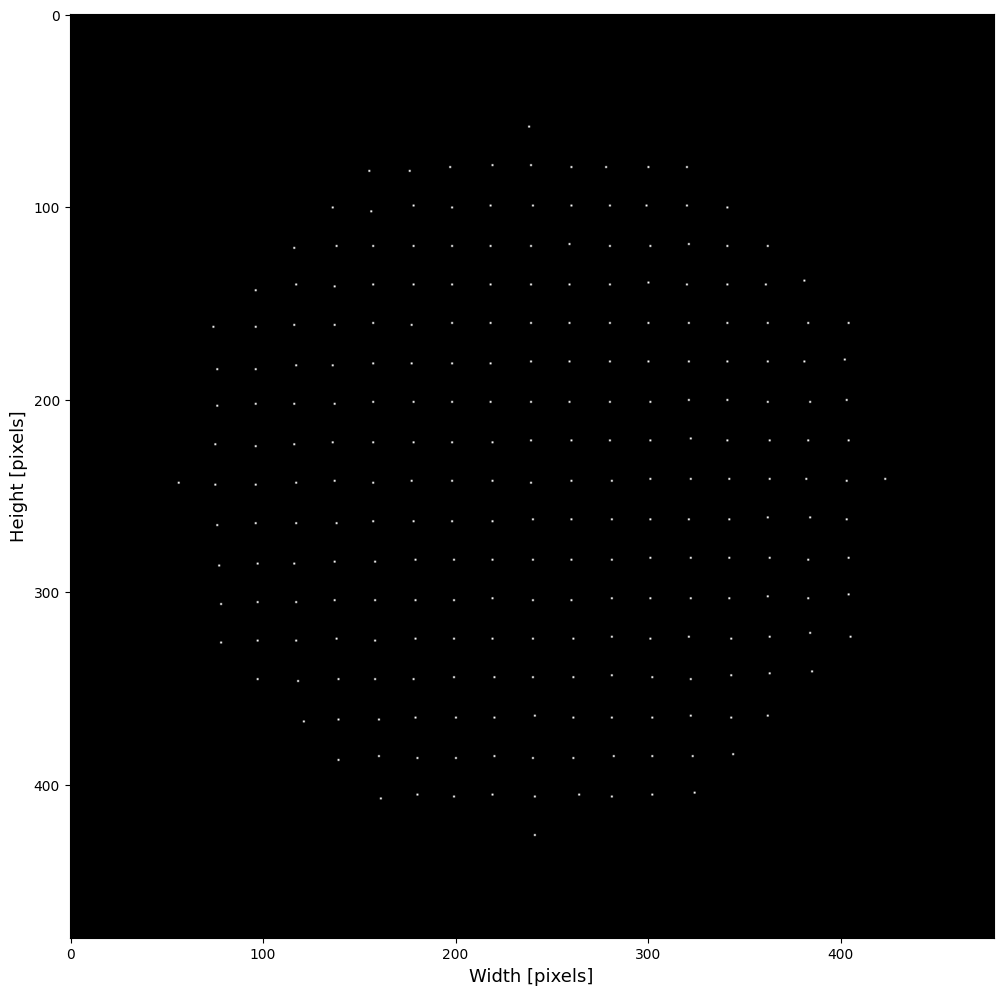

In [102]:
plt.figure(figsize=(12,12))
plt.imshow(matA_hpref, cmap="grey")
plt.xlabel('Width [pixels]', size=13)
plt.ylabel('Height [pixels]', size=13)